<a href="https://colab.research.google.com/github/Efe-Godson/3mtt-stage2-analysis/blob/main/notebooks/deliverable_2_analysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3MTT STAGE 2: Data Analysis Notebook

**TABLE OF CONTENT**

# 1. ENVIRONMENT SETUP AND LIBRARY IMPORTS

In [107]:
# CORE LIBRARIES

# Data manipulation
import pandas as pd
import numpy as np

# SQLite database connection
import sqlite3

# Date handling
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#Regular Expression operator
import re

# For data manipulation and viz
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
import requests
from io import BytesIO

#stastical library
from scipy.stats import chi2_contingency

#2. DATA LOADING

Raw datasets are loaded directly from the GitHub repository

In [28]:
# Loading raw data

# Fellows cohort dataset
fellows = pd.read_csv("https://raw.githubusercontent.com/Efe-Godson/3mtt-stage2-analysis/main/raw_data/fellows_cohort.csv")

# Reflection survey dataset
reflection = pd.read_excel("https://raw.githubusercontent.com/Efe-Godson/3mtt-stage2-analysis/main/raw_data/reflection_survey.xlsx", skiprows=1)

# Employer engagement dataset
employer = pd.read_csv("https://raw.githubusercontent.com/Efe-Godson/3mtt-stage2-analysis/main/raw_data/employer_engagement.csv")

# ALC weekly operational logs
alc_logs = pd.read_csv("https://raw.githubusercontent.com/Efe-Godson/3mtt-stage2-analysis/main/raw_data/alc_weekly_log.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 2.1 STRUCTURAL ISSUE - Reflection Survey File

The reflection survey dataset included an extra merged row above the actual column headers.

The file was loaded using the `skiprows=1` parameter in `pandas.read_excel()` so the correct headers could be captured properly.

This prevented column alignment issues later in the analysis.

#3. INITIAL DATA FAMILIARIZATION

## 3.1 STRUCTURAL INSPECTION

In [29]:
from IPython.display import display, HTML


# Store datasets in a dictionary
datasets = {
    "Fellows Cohort": fellows,
    "Reflection Survey": reflection,
    "Employer Engagement": employer,
    "ALC Weekly Logs": alc_logs
}


# Start responsive grid container
html_content = """
<div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(420px, 1fr));
    gap:20px;
    width:100%;
">
"""


# Generate overview cards
for name, df in datasets.items():

    html_content += f"""

    <div style="
        border:1px solid #d9d9d9;
        border-radius:12px;
        padding:18px;
        background-color:white;
        box-shadow:2px 2px 10px rgba(0,0,0,0.08);
        overflow-x:auto;
    ">

        <h2 style="color:#1f4e79; margin-top:0;">
            {name}
        </h2>

        <hr>

        <p><strong>Rows:</strong> {df.shape[0]}</p>
        <p><strong>Columns:</strong> {df.shape[1]}</p>

        <h4>Column Names</h4>

        <div style="
            background-color:#f7f7f7;
            padding:10px;
            border-radius:6px;
            font-size:13px;
            max-height:120px;
            overflow-y:auto;
        ">
            {", ".join(df.columns)}
        </div>

        <h4 style="margin-top:20px;">
            Data Types
        </h4>

        {df.dtypes.to_frame(name='dtype').to_html(index=True)}

    </div>

    """


# Close grid container
html_content += "</div>"


# Render overview dashboard
display(HTML(html_content))

,dtype
fellow_id,object
first_name,object
last_name,object
state,object
alc_code,object
cohort_number,int64
track,object
enrollment_date,object
completion_status,object
certification_status,object


## 3.2 SAMPLE RECORD INSPECTION

In [30]:
# Display sample records from each dataset
for name, df in datasets.items():

    print(f"\n{'='*60}")
    print(f"{name.upper()} - SAMPLE RECORDS")
    print(f"{'='*60}")

    display(df.head())


FELLOWS COHORT - SAMPLE RECORDS


,fellow_id,first_name,last_name,state,alc_code,cohort_number,track,enrollment_date,completion_status,certification_status
0,3MTT-F00001,Halima,Musa,niger,ALC-013,3,AI/ML,2024-07-27,complete,certified
1,3MTT-F00002,Grace,Okafor,Ebonyi,ALC-037,4,Cybersecurity,2024-02-20,complete,certified
2,3MTT-F00003,Yusuf,Yakubu,Edo,ALC-041,4,Data Analysis,2024-10-26,complete,certified
3,3MTT-F00004,Ekene,Afolabi,Kaduna,ALC-005,4,AI/ML,2024-08-07,complete,certified
4,3MTT-F00005,Grace,Abubakar,Jigawa,ALC-031,4,Cloud Computing,2024-09-05,complete,certified



REFLECTION SURVEY - SAMPLE RECORDS


,fellow_id,week,response_timestamp,survey_score,phone_number,email
0,3MTT-F00001,1,2024-02-05 16:00:00,2.2,+2348165956164,3mtt.f00001@gmail.com
1,3MTT-F00001,2,2024-02-14 13:00:00,4.9,2347067490250,3mtt.f00001@gmail.com
2,3MTT-F00001,4,2024-03-01 11:00:00,4.4,2349058953690,3mtt.f00001@gmail.com
3,3MTT-F00001,5,2024-03-09 09:00:00,4.9,0816-989-8681,3mtt.f00001@yahoo.com
4,3MTT-F00001,7,2024-03-23 16:00:00,3.6,+2347064394353,3mtt.f00001@yahoo.com



EMPLOYER ENGAGEMENT - SAMPLE RECORDS


,employer_name,sector,state,geopolitical_zone,engagement_type,engagement_date,alc_code,fellows_referred
0,Nestle Nigeria,FMCG,Niger,North-Central,webinar,2024-12-31,ALC-045,0
1,Nestle Nigeria,FMCG,Lagos,South-West,fair,2024-03-10,ALC-016,4
2,Tek Experts,Technology,Borno,North-East,placement,2024-10-08,ALC-030,13
3,Inlaks,Technology,Ekiti,South-West,bootcamp,2024-09-29,ALC-040,0
4,Helium Health,HealthTech,Zamfara,North-West,placement,2024-08-03,ALC-037,13



ALC WEEKLY LOGS - SAMPLE RECORDS


,alc_code,week_number,state,geopolitical_zone,fellows_present,sessions_held,facilitator_name,data_quality_flag
0,ALC-001,1,Adamawa,North-East,15,5,Fatima Aliyu,OK
1,ALC-001,2,Adamawa,North-East,7,2,Fatima Aliyu,LOW_ATTENDANCE
2,ALC-001,3,Adamawa,North-East,10,4,Fatima Aliyu,OK
3,ALC-001,4,Adamawa,North-East,9,3,Fatima Aliyu,OK
4,ALC-001,5,Adamawa,North-East,14,3,Fatima Aliyu,OK


##3.3 MISSING VALUE OVERVIEW

In [31]:
# Display missing value summaries across datasets
for name, df in datasets.items():

    missing_summary = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (
            df.isnull().mean() * 100
        ).round(2)
    })

    missing_summary = (
        missing_summary[
            missing_summary["Missing Values"] > 0
        ]
        .sort_values(
            by="Missing Values",
            ascending=False
        )
    )


    # Display only datasets containing missing values
    if not missing_summary.empty:

        print(f"\n{name}")

        display(
            missing_summary.style
            .background_gradient(
                cmap="Oranges",
                subset=["Missing Percentage"]
            )
            .format({
                "Missing Percentage": "{:.2f}%"
            })
        )


Fellows Cohort


,Missing Values,Missing Percentage
alc_code,47,4.00%



Employer Engagement


,Missing Values,Missing Percentage
alc_code,22,5.12%



ALC Weekly Logs


,Missing Values,Missing Percentage
alc_code,20,3.02%


## 3.4 DUPLICATE RECORD OVERVIEW

In [32]:
# Analyze duplicate records across datasets
for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    duplicate_percentage = round(
        (duplicate_count / len(df)) * 100,
        2
    )


    # Display duplicate summary for each dataset
    duplicate_summary = pd.DataFrame({
        "Duplicate Records": [duplicate_count],
        "Duplicate Percentage": [duplicate_percentage]
    })

    print(f"\n{name}")

    display(
        duplicate_summary.style
        .background_gradient(
            cmap="Reds",
            subset=["Duplicate Percentage"]
        )
        .format({
            "Duplicate Percentage": "{:.2f}%"
        })
    )


Fellows Cohort


,Duplicate Records,Duplicate Percentage
0,20,1.70%



Reflection Survey


,Duplicate Records,Duplicate Percentage
0,30,0.30%



Employer Engagement


,Duplicate Records,Duplicate Percentage
0,5,1.16%



ALC Weekly Logs


,Duplicate Records,Duplicate Percentage
0,15,2.26%


## 3.6 UNIQUE VALUE INSPECTION

In [33]:
# Inspect categorical uniqueness across datasets
for name, df in datasets.items():

    print(f"\n{name}")


    # Select categorical columns for inspection
    categorical_columns = df.select_dtypes(
        include="object"
    ).columns


    # Generate unique value summary
    unique_summary = pd.DataFrame({
        "Unique Values": [
            df[col].nunique()
            for col in categorical_columns
        ]
    },
    index=categorical_columns)


    # Display categorical uniqueness overview
    display(
        unique_summary.style
        .background_gradient(
            cmap="Blues"
        )
    )


Fellows Cohort


,Unique Values
fellow_id,1150
first_name,25
last_name,25
state,103
alc_code,54
track,8
enrollment_date,286
completion_status,2
certification_status,2



Reflection Survey


,Unique Values
fellow_id,1150
response_timestamp,1092
phone_number,9944
email,2243



Employer Engagement


,Unique Values
employer_name,29
sector,10
state,62
geopolitical_zone,6
engagement_type,5
engagement_date,257
alc_code,54



ALC Weekly Logs


,Unique Values
alc_code,54
state,29
geopolitical_zone,6
facilitator_name,15
data_quality_flag,2


## 3.7 NUMERICAL VARIABLE SUMMARY

In [34]:
# Inspect numerical distributions across datasets
for name, df in datasets.items():


    # Select numerical columns
    numerical_columns = df.select_dtypes(
        include=["int64", "float64"]
    )


    # Skip datasets without numerical columns
    if not numerical_columns.empty:

        print(f"\n{name}")


        # Generate descriptive statistics
        numerical_summary = (
            numerical_columns
            .describe()
            .T
            .round(2)
        )


        # Display numerical summary table
        display(
            numerical_summary.style
            .background_gradient(
                cmap="Greens"
            )
        )


Fellows Cohort


,count,mean,std,min,25%,50%,75%,max
cohort_number,1175.000000,3.520000,0.500000,3.000000,3.000000,4.000000,4.000000,4.000000



Reflection Survey


,count,mean,std,min,25%,50%,75%,max
week,9974.000000,6.510000,3.470000,1.000000,3.000000,7.000000,10.000000,12.000000
survey_score,9974.000000,3.510000,0.870000,2.000000,2.800000,3.500000,4.300000,5.000000



Employer Engagement


,count,mean,std,min,25%,50%,75%,max
fellows_referred,430.000000,5.040000,8.610000,0.000000,0.000000,0.000000,7.000000,30.000000



ALC Weekly Logs


,count,mean,std,min,25%,50%,75%,max
week_number,663.000000,7.170000,8.720000,1.000000,3.500000,7.000000,9.000000,99.000000
fellows_present,663.000000,13.380000,7.590000,2.000000,8.000000,12.000000,17.500000,39.000000
sessions_held,663.000000,3.520000,1.120000,2.000000,2.000000,4.000000,4.500000,5.000000


## 3.8 TEMPORAL VARIABLE INSPECTION

In [35]:
# Inspect date and time-related columns across datasets
for name, df in datasets.items():

    # Identify columns containing date or time keywords
    datetime_columns = [
        col for col in df.columns
        if "date" in col.lower()
        or "time" in col.lower()
    ]


    # Skip datasets without temporal columns
    if len(datetime_columns) > 0:

        print(f"\n{name}")


        # Create a quick preview of temporal fields
        temporal_summary = pd.DataFrame({
            "Column": datetime_columns,
            "Sample Values": [
                df[col]
                .dropna()
                .astype(str)
                .unique()[:3]
                for col in datetime_columns
            ]
        })


        # Display temporal inspection summary
        display(
            temporal_summary.style
            .background_gradient(cmap="Purples")
        )


Fellows Cohort


,Column,Sample Values
0,enrollment_date,['2024-07-27' '2024-02-20' '2024-10-26']



Reflection Survey


,Column,Sample Values
0,response_timestamp,['2024-02-05 16:00:00' '2024-02-14 13:00:00' '2024-03-01 11:00:00']



Employer Engagement


,Column,Sample Values
0,engagement_date,['2024-12-31' '2024-03-10' '2024-10-08']


The temporal fields loaded successfully across the datasets and generally followed a consistent date structure.

The reflection survey dataset contained timestamp values, while the remaining datasets used date-only fields.

No obvious formatting issues were identified during the initial inspection.

# 4.  DATA CLEANING AND STANDARDISATION

## 4.1 STANDARDIZE STRUCTURAL CONSISTENCY

In [36]:
# Create copies of the raw datasets before transformation
fellows_clean = fellows.copy()
reflection_clean = reflection.copy()
employer_clean = employer.copy()
alc_logs_clean = alc_logs.copy()


# Store cleaned datasets in a dictionary for easier iteration
cleaned_datasets = {
    "Fellows Cohort": fellows_clean,
    "Reflection Survey": reflection_clean,
    "Employer Engagement": employer_clean,
    "ALC Weekly Logs": alc_logs_clean
}


# ---------------------------------------------------------
# Standardize temporal columns across datasets
# ---------------------------------------------------------


# Convert enrollment dates into datetime format
fellows_clean["enrollment_date"] = pd.to_datetime(
    fellows_clean["enrollment_date"],
    errors="coerce"
)


# Convert survey timestamps into datetime format
reflection_clean["response_timestamp"] = pd.to_datetime(
    reflection_clean["response_timestamp"],
    errors="coerce"
)


# Convert employer engagement dates into datetime format
employer_clean["engagement_date"] = pd.to_datetime(
    employer_clean["engagement_date"],
    errors="coerce"
)


# ---------------------------------------------------------
# Validate datetime parsing results
# ---------------------------------------------------------


# Store temporal validation summaries
temporal_validation = pd.DataFrame({

    "Dataset": [
        "Fellows Cohort",
        "Reflection Survey",
        "Employer Engagement"
    ],

    "Temporal Column": [
        "enrollment_date",
        "response_timestamp",
        "engagement_date"
    ],

    "Null Values After Parsing": [
        fellows_clean["enrollment_date"].isnull().sum(),
        reflection_clean["response_timestamp"].isnull().sum(),
        employer_clean["engagement_date"].isnull().sum()
    ]

})


# Display datetime validation results
display(
    temporal_validation.style
    .background_gradient(
        cmap="Purples",
        subset=["Null Values After Parsing"]
    )
)


# ---------------------------------------------------------
# Standardize categorical location fields
# ---------------------------------------------------------


# Normalize state formatting in fellows dataset
fellows_clean["state"] = (
    fellows_clean["state"]
    .str.strip()
    .str.title()
)


# Normalize state formatting in employer dataset
employer_clean["state"] = (
    employer_clean["state"]
    .str.strip()
    .str.title()
)


# Normalize state formatting in ALC logs dataset
alc_logs_clean["state"] = (
    alc_logs_clean["state"]
    .str.strip()
    .str.title()
)


# ---------------------------------------------------------
# Recheck categorical consistency after standardization
# ---------------------------------------------------------


# Compare unique state counts after cleaning
state_validation = pd.DataFrame({

    "Dataset": [
        "Fellows Cohort",
        "Employer Engagement",
        "ALC Weekly Logs"
    ],

    "Unique States": [
        fellows_clean["state"].nunique(),
        employer_clean["state"].nunique(),
        alc_logs_clean["state"].nunique()
    ]

})


# Display state validation summary
display(
    state_validation.style
    .background_gradient(
        cmap="Blues",
        subset=["Unique States"]
    )
)


# ---------------------------------------------------------
# Inspect standardized temporal samples
# ---------------------------------------------------------


# Display cleaned temporal samples for validation
temporal_samples = pd.DataFrame({

    "Enrollment Date": fellows_clean["enrollment_date"].head(3),

    "Response Timestamp": (
        reflection_clean["response_timestamp"].head(3)
        .reset_index(drop=True)
    ),

    "Engagement Date": (
        employer_clean["engagement_date"].head(3)
        .reset_index(drop=True)
    )

})


# Render temporal validation samples
display(temporal_samples)

,Dataset,Temporal Column,Null Values After Parsing
0,Fellows Cohort,enrollment_date,0
1,Reflection Survey,response_timestamp,0
2,Employer Engagement,engagement_date,0


,Dataset,Unique States
0,Fellows Cohort,37
1,Employer Engagement,37
2,ALC Weekly Logs,29


,Enrollment Date,Response Timestamp,Engagement Date
0,2024-07-27,2024-02-05 16:00:00,2024-12-31
1,2024-02-20,2024-02-14 13:00:00,2024-03-10
2,2024-10-26,2024-03-01 11:00:00,2024-10-08


The temporal fields were successfully converted into datetime format without any parsing issues. This confirms that the date-related fields were structurally consistent across the datasets.

State names were also standardized to improve categorical consistency. Earlier variations such as `niger`, `IMO`, and `Lagos` were normalized into a consistent format, making the location fields more reliable for downstream analysis and grouping operations.

## 4.2 CLEAN IDENTITY & CONTACT FIELDS

In [37]:
# Inspect raw phone number patterns

# Create a working copy of the phone number column
phone_audit = reflection_clean.copy()


# Store original phone numbers for comparison
phone_audit["phone_original"] = (
    phone_audit["phone_number"]
    .astype(str)
)


# Extract only numeric characters
phone_audit["phone_digits"] = (
    phone_audit["phone_original"]
    .str.replace(r"\D", "", regex=True)
)


# Analyze phone number lengths before cleaning
phone_length_before = (
    phone_audit["phone_digits"]
    .str.len()
    .value_counts()
    .sort_index()
    .reset_index()
)

phone_length_before.columns = [
    "Phone Length",
    "Record Count"
]


# Display raw phone structure distribution
display(
    phone_length_before.style
    .background_gradient(cmap="Oranges")
)


# Standardize Nigerian phone number format

# Define phone number cleaning function
def standardize_nigerian_phone(phone):

    # Convert values to string format
    phone = str(phone)


    # Remove non-numeric characters
    phone = re.sub(r"\D", "", phone)


    # Remove extra leading international zeros
    if phone.startswith("00"):
        phone = phone[2:]


    # Convert local Nigerian format
    if len(phone) == 11 and phone.startswith("0"):
        phone = "234" + phone[1:]


    # Convert short 10-digit numbers
    elif len(phone) == 10:
        phone = "234" + phone


    # Validate final structure
    if len(phone) == 13 and phone.startswith("234"):
        return phone


    # Return invalid values as NaN
    return np.nan


# Apply phone standardization
reflection_clean["phone_clean"] = (
    reflection_clean["phone_number"]
    .apply(standardize_nigerian_phone)
)


# Validate phone cleaning results

# Count valid standardized numbers
valid_phone_count = (
    reflection_clean["phone_clean"]
    .notnull()
    .sum()
)


# Count invalid phone records
invalid_phone_count = (
    reflection_clean["phone_clean"]
    .isnull()
    .sum()
)


# Compare unique phone formats before and after cleaning
phone_validation = pd.DataFrame({

    "Metric": [
        "Valid Standardized Numbers",
        "Invalid Remaining Values",
        "Unique Raw Phone Values",
        "Unique Clean Phone Values"
    ],

    "Count": [
        valid_phone_count,
        invalid_phone_count,
        reflection_clean["phone_number"].nunique(),
        reflection_clean["phone_clean"].nunique()
    ]

})


# Display phone validation summary
display(
    phone_validation.style
    .background_gradient(
        cmap="Greens",
        subset=["Count"]
    )
)


# Compare raw and cleaned phone samples

# Display before-and-after phone comparison
phone_comparison = reflection_clean[[
    "phone_number",
    "phone_clean"
]].head(15)


# Render phone transformation samples
display(phone_comparison)

,Phone Length,Record Count
0,10,1686
1,11,3304
2,12,1694
3,13,3290


,Metric,Count
0,Valid Standardized Numbers,9974
1,Invalid Remaining Values,0
2,Unique Raw Phone Values,9944
3,Unique Clean Phone Values,9942


,phone_number,phone_clean
0,+2348165956164,2348165956164
1,2347067490250,2347067490250
2,2349058953690,2349058953690
3,0816-989-8681,2348169898681
4,+2347064394353,2347064394353
5,+2348167651588,2348167651588
6,0810-392-8369,2348103928369
7,008066682973,2348066682973
8,2349057120602,2349057120602
9,+2347062683415,2347062683415


The phone number field contained several inconsistent formats, including local Nigerian numbers, values with symbols, and numbers with extra leading zeros.

Numbers beginning with `0` were converted into the international Nigerian format by replacing the leading zero with `234`. Symbols such as `+` and `-` were removed, while values beginning with `00` were corrected before standardization.

After cleaning, all phone numbers were successfully converted into the required `234XXXXXXXXXX` structure, making the field more consistent for identity matching and deduplication.

## 4.3 HANDLE MISSING DATA

In [38]:

# Inspect missing alc_code values across datasets
alc_missing_summary = pd.DataFrame({

    "Dataset": [
        "Fellows Cohort",
        "Employer Engagement"
    ],

    "Missing alc_code Values": [
        fellows_clean["alc_code"].isnull().sum(),
        employer_clean["alc_code"].isnull().sum()
    ]

})


# Display missing alc_code summary
display(
    alc_missing_summary.style
    .background_gradient(
        cmap="Oranges",
        subset=["Missing alc_code Values"]
    )
)


# Review records with missing alc_code values
missing_alc_fellows = (
    fellows_clean[
        fellows_clean["alc_code"].isnull()
    ]
)

missing_alc_employer = (
    employer_clean[
        employer_clean["alc_code"].isnull()
    ]
)


# Display affected fellows records
display(missing_alc_fellows.head())


# Display affected employer engagement records
display(missing_alc_employer.head())


# Assess whether alc_code values can be inferred
# using related categorical fields
alc_inference_check = (
    fellows_clean.groupby(
        ["state", "track"]
    )["alc_code"]
    .nunique()
    .reset_index()
)


# Display grouped ALC distribution samples
display(alc_inference_check.head(10))

,Dataset,Missing alc_code Values
0,Fellows Cohort,47
1,Employer Engagement,22


,fellow_id,first_name,last_name,state,alc_code,cohort_number,track,enrollment_date,completion_status,certification_status
147,3MTT-F00148,Yusuf,Aliyu,Abuja,NaN,4,Cloud Computing,2024-05-02,incomplete,not certified
150,3MTT-F00151,Ifeanyi,Adegoke,Kogi,NaN,3,Product Management,2024-09-06,incomplete,not certified
157,3MTT-F00158,Nnamdi,Lawal,Oyo,NaN,4,Cloud Computing,2024-04-01,complete,certified
164,3MTT-F00165,Fatima,Olawale,Anambra,NaN,3,Cybersecurity,2024-07-12,complete,certified
193,3MTT-F00194,Nnamdi,Garba,Benue,NaN,4,AI/ML,2024-02-01,complete,certified


,employer_name,sector,state,geopolitical_zone,engagement_type,engagement_date,alc_code,fellows_referred
101,Flutterwave,Fintech,Ebonyi,South-East,webinar,2024-03-31,NaN,0
104,Nigerian Breweries,FMCG,Rivers,South-South,placement,2025-02-28,NaN,11
113,Konga,E-commerce,Anambra,South-East,MOU,2024-08-29,NaN,0
135,Nestle Nigeria,FMCG,Edo,South-South,bootcamp,2024-10-15,NaN,0
165,MTN Nigeria,Telecoms,Ekiti,South-West,bootcamp,2024-12-01,NaN,0


,state,track,alc_code
0,Abia,AI/ML,3
1,Abia,Cloud Computing,4
2,Abia,Cybersecurity,6
3,Abia,Data Analysis,2
4,Abia,DevOps,4
5,Abia,Product Management,5
6,Abia,Software Development,5
7,Abia,UI/UX Design,2
8,Abuja,AI/ML,1
9,Abuja,Cloud Computing,1


**Sequential ALC Code Repair**

The ALC weekly logs were reviewed separately before validating the missing `alc_code` values across datasets.

Some weekly operational records contained missing ALC codes despite following continuous weekly sequences.

These missing values were therefore repaired using forward-fill and backward-fill logic before continuing with the mapping validation process.

In [39]:
# Sort operational logs sequentially
alc_logs_clean = (
    alc_logs_clean
    .sort_values(
        by=["state", "week_number"]
    )
)


# Fill missing ALC codes sequentially
alc_logs_clean["alc_code"] = (
    alc_logs_clean["alc_code"]
    .ffill()
    .bfill()
)


# Validate remaining missing values
print(
    "Remaining missing alc_code values:",
    alc_logs_clean["alc_code"].isnull().sum()
)

Remaining missing alc_code values: 0


In [40]:
# Compare state values across all datasets

# Extract unique states from each dataset
fellows_states = set(
    fellows_clean["state"]
    .dropna()
    .str.strip()
    .str.title()
    .unique()
)

employer_states = set(
    employer_clean["state"]
    .dropna()
    .str.strip()
    .str.title()
    .unique()
)

alc_states = set(
    alc_logs_clean["state"]
    .dropna()
    .str.strip()
    .str.title()
    .unique()
)


# Build comparison summary
state_comparison = pd.DataFrame({

    "Dataset": [
        "Fellows Cohort",
        "Employer Engagement",
        "ALC Weekly Logs"
    ],

    "Unique States": [
        len(fellows_states),
        len(employer_states),
        len(alc_states)
    ]

})


# Display state summary
display(
    state_comparison.style
    .background_gradient(
        cmap="Blues",
        subset=["Unique States"]
    )
)


# Identify states missing across datasets
fellows_not_in_alc = sorted(
    fellows_states - alc_states
)

employer_not_in_alc = sorted(
    employer_states - alc_states
)


# Display unmatched states
print(
    "Fellows states not found in ALC logs:",
    fellows_not_in_alc
)

print(
    "Employer states not found in ALC logs:",
    employer_not_in_alc
)

,Dataset,Unique States
0,Fellows Cohort,37
1,Employer Engagement,37
2,ALC Weekly Logs,29


Fellows states not found in ALC logs: ['Abia', 'Akwa Ibom', 'Ekiti', 'Kwara', 'Ogun', 'Rivers', 'Taraba', 'Zamfara']
Employer states not found in ALC logs: ['Abia', 'Akwa Ibom', 'Ekiti', 'Kwara', 'Ogun', 'Rivers', 'Taraba', 'Zamfara']


**Mapping Validation**

After validating state coverage across datasets, additional mapping checks were performed to determine whether missing `alc_code` values could be inferred reliably using operational and enrollment-level features.

In [41]:
# Create enrollment week feature
fellows_clean["enrollment_week"] = (
    fellows_clean["enrollment_date"]
    .dt.isocalendar()
    .week
)


# Build refined ALC mapping validation table
alc_mapping_validation = (
    fellows_clean.groupby(
        [
            "state",
            "track",
            "cohort_number",
            "enrollment_week"
        ]
    )["alc_code"]
    .agg(
        unique_alc_count=lambda x: x.dropna().nunique(),
        alc_codes=lambda x: sorted(x.dropna().unique())
    )
    .reset_index()
)


# Identify only ambiguous mappings
ambiguous_alc_mappings = (
    alc_mapping_validation[
        alc_mapping_validation["unique_alc_count"] > 1
    ]
)


# Display ambiguous combinations
display(ambiguous_alc_mappings)


# Display ambiguity count
print(
    f"Ambiguous combinations found: "
    f"{len(ambiguous_alc_mappings)}"
)

,state,track,cohort_number,enrollment_week,unique_alc_count,alc_codes
13,Abia,Cybersecurity,4,35,2,"[ALC-002, ALC-030]"
105,Akwa Ibom,DevOps,3,33,2,"[ALC-003, ALC-049]"
225,Benue,Software Development,3,21,2,"[ALC-002, ALC-017]"
344,Ebonyi,Data Analysis,3,39,2,"[ALC-037, ALC-038]"
527,Jigawa,AI/ML,4,7,2,"[ALC-014, ALC-031]"
816,Ogun,Cloud Computing,4,15,2,"[ALC-003, ALC-013]"
829,Ogun,Product Management,3,40,2,"[ALC-024, ALC-030]"
835,Ogun,Software Development,4,5,2,"[ALC-020, ALC-051]"
851,Ondo,Cloud Computing,3,36,2,"[ALC-008, ALC-042]"


Ambiguous combinations found: 9


**Observations**

Most records matched clearly to a single ALC code after combining:
- state
- track
- cohort number
- enrollment week

This means the missing ALC codes could be filled safely for most records.

However, 9 combinations still matched to more than one ALC code. These records were left unchanged to avoid assigning the wrong ALC.

In [42]:
# PASS 1: Build the mapping dict (state + track + cohort + enrollment_week)
map_1 = (
    fellows_clean[fellows_clean["alc_code"].notna()]
    .groupby(["state", "track", "cohort_number", "enrollment_week"])["alc_code"]
    .agg(lambda x: x.iloc[0] if x.nunique() == 1 else np.nan)
    .dropna()
    .to_dict()
)

# Apply Pass 1
fellows_clean["alc_code"] = fellows_clean.apply(
    lambda row: map_1.get(
        (row["state"], row["track"], row["cohort_number"], row["enrollment_week"]),
        row["alc_code"]
    ) if pd.isna(row["alc_code"]) else row["alc_code"],
    axis=1
)

# PASS 2: state + track + cohort_number
map_2 = (
    fellows_clean[fellows_clean["alc_code"].notna()]
    .groupby(["state", "track", "cohort_number"])["alc_code"]
    .agg(lambda x: x.iloc[0] if x.nunique() == 1 else np.nan)
    .dropna()
    .to_dict()
)

fellows_clean["alc_code"] = fellows_clean.apply(
    lambda row: map_2.get(
        (row["state"], row["track"], row["cohort_number"]),
        row["alc_code"]
    ) if pd.isna(row["alc_code"]) else row["alc_code"],
    axis=1
)

# PASS 3: state + track
map_3 = (
    fellows_clean[fellows_clean["alc_code"].notna()]
    .groupby(["state", "track"])["alc_code"]
    .agg(lambda x: x.iloc[0] if x.nunique() == 1 else np.nan)
    .dropna()
    .to_dict()
)

fellows_clean["alc_code"] = fellows_clean.apply(
    lambda row: map_3.get(
        (row["state"], row["track"]),
        row["alc_code"]
    ) if pd.isna(row["alc_code"]) else row["alc_code"],
    axis=1
)

In [43]:
print("Rows before:", len(fellows))       # original
print("Rows after:", len(fellows_clean))  # should match

Rows before: 1175
Rows after: 1175


In [44]:
# FINAL NULL VALIDATION

# Build final missing value summary
final_missing_summary = pd.DataFrame({

    "Dataset": [
        "Fellows Cohort",
        "Employer Engagement",
        "ALC Weekly Logs"
    ],

    "Remaining Missing alc_code": [
        fellows_clean["alc_code"].isnull().sum(),
        employer_clean["alc_code"].isnull().sum(),
        alc_logs_clean["alc_code"].isnull().sum()
    ]

})


# Display final validation summary
display(
    final_missing_summary.style
    .background_gradient(
        cmap="Oranges",
        subset=["Remaining Missing alc_code"]
    )
)

,Dataset,Remaining Missing alc_code
0,Fellows Cohort,9
1,Employer Engagement,22
2,ALC Weekly Logs,0


**Filling Summary**

The missing `alc_code` values were filled using a staged matching process.

The process started by repairing the missing ALC codes inside the ALC weekly logs using forward-fill and backward-fill logic. This created a cleaner operational reference table for downstream validation.

Next, state values were compared across all datasets to confirm structural consistency and identify states missing from the operational logs.

Additional mapping checks were then performed using:
- state
- track
- cohort number
- enrollment week

These combinations were used to test whether records mapped consistently to a single ALC code.

The filling process was applied in multiple stages:
- First using `state + track + cohort_number + enrollment_week`
- Then using `state + track + cohort_number`
- Finally using `state + track`

At each stage, records were only filled when the combination mapped to one unique ALC code. Any combinations linked to multiple ALC codes were treated as ambiguous and were not filled.

This approach allowed most missing values to be resolved safely while preserving the integrity of records that could not be matched confidently.

In [45]:
# DISPLAY REMAINING UNRESOLVED RECORDS

# Filter records with unresolved ALC codes
remaining_unresolved = (
    fellows_clean[
        fellows_clean["alc_code"].isnull()
    ]
)


# Select key validation columns
remaining_unresolved = (
    remaining_unresolved[
        [
            "fellow_id",
            "state",
            "track",
            "cohort_number",
            "enrollment_week",
            "completion_status",
            "alc_code"
        ]
    ]
)


# Display unresolved records
display(remaining_unresolved)


# Display unresolved record count
print(
    f"Remaining unresolved records: "
    f"{len(remaining_unresolved)}"
)

,fellow_id,state,track,cohort_number,enrollment_week,completion_status,alc_code
323,3MTT-F00324,Ekiti,Product Management,4,33,complete,NaN
352,3MTT-F00353,Kaduna,Software Development,3,33,incomplete,NaN
427,3MTT-F00428,Osun,AI/ML,4,9,complete,NaN
469,3MTT-F00470,Yobe,Cybersecurity,4,28,incomplete,NaN
851,3MTT-F00852,Plateau,AI/ML,4,40,complete,NaN
937,3MTT-F00938,Benue,Software Development,3,20,incomplete,NaN
999,3MTT-F01000,Jigawa,Data Analysis,4,43,complete,NaN
1043,3MTT-F01044,Ekiti,DevOps,4,31,incomplete,NaN
1121,3MTT-F01122,Adamawa,Cybersecurity,4,5,complete,NaN


Remaining unresolved records: 9


**Remaining Unresolved Records**

The final unresolved records fell into two groups.

The first group involved states such as Ekiti that did not appear in the operational ALC weekly logs. These records could not be validated against an operational reference source.

The second group involved states such as Kaduna, Osun, Yobe, Plateau, Benue, Jigawa, and Adamawa. These states existed in the operational logs but mapped to multiple valid ALC codes across different operational patterns.

Because these records could not be matched to one unique ALC code confidently, they were left unchanged.

In [46]:
# CREATE ACTIVE WORKING TABLES

# Create working copies for downstream processing
fellows_working = fellows_clean.copy()

reflection_working = reflection_clean.copy()

employer_working = employer_clean.copy()

alc_logs_working = alc_logs_clean.copy()


# Display working table shapes
print("Fellows Cohort:", fellows_working.shape)

print("Reflection Survey:", reflection_working.shape)

print("Employer Engagement:", employer_working.shape)

print("ALC Weekly Logs:", alc_logs_working.shape)


# Preview working datasets
display(fellows_working.head())

display(reflection_working.head())

display(employer_working.head())

display(alc_logs_working.head())

Fellows Cohort: (1175, 11)
Reflection Survey: (9974, 7)
Employer Engagement: (430, 8)
ALC Weekly Logs: (663, 8)


,fellow_id,first_name,last_name,state,alc_code,cohort_number,track,enrollment_date,completion_status,certification_status,enrollment_week
0,3MTT-F00001,Halima,Musa,Niger,ALC-013,3,AI/ML,2024-07-27,complete,certified,30
1,3MTT-F00002,Grace,Okafor,Ebonyi,ALC-037,4,Cybersecurity,2024-02-20,complete,certified,8
2,3MTT-F00003,Yusuf,Yakubu,Edo,ALC-041,4,Data Analysis,2024-10-26,complete,certified,43
3,3MTT-F00004,Ekene,Afolabi,Kaduna,ALC-005,4,AI/ML,2024-08-07,complete,certified,32
4,3MTT-F00005,Grace,Abubakar,Jigawa,ALC-031,4,Cloud Computing,2024-09-05,complete,certified,36


,fellow_id,week,response_timestamp,survey_score,phone_number,email,phone_clean
0,3MTT-F00001,1,2024-02-05 16:00:00,2.2,+2348165956164,3mtt.f00001@gmail.com,2348165956164
1,3MTT-F00001,2,2024-02-14 13:00:00,4.9,2347067490250,3mtt.f00001@gmail.com,2347067490250
2,3MTT-F00001,4,2024-03-01 11:00:00,4.4,2349058953690,3mtt.f00001@gmail.com,2349058953690
3,3MTT-F00001,5,2024-03-09 09:00:00,4.9,0816-989-8681,3mtt.f00001@yahoo.com,2348169898681
4,3MTT-F00001,7,2024-03-23 16:00:00,3.6,+2347064394353,3mtt.f00001@yahoo.com,2347064394353


,employer_name,sector,state,geopolitical_zone,engagement_type,engagement_date,alc_code,fellows_referred
0,Nestle Nigeria,FMCG,Niger,North-Central,webinar,2024-12-31,ALC-045,0
1,Nestle Nigeria,FMCG,Lagos,South-West,fair,2024-03-10,ALC-016,4
2,Tek Experts,Technology,Borno,North-East,placement,2024-10-08,ALC-030,13
3,Inlaks,Technology,Ekiti,South-West,bootcamp,2024-09-29,ALC-040,0
4,Helium Health,HealthTech,Zamfara,North-West,placement,2024-08-03,ALC-037,13


,alc_code,week_number,state,geopolitical_zone,fellows_present,sessions_held,facilitator_name,data_quality_flag
288,ALC-025,1,Abuja,North-Central,15,2,Adewale Okafor,LOW_ATTENDANCE
289,ALC-025,2,Abuja,North-Central,27,4,Adewale Okafor,OK
290,ALC-025,3,Abuja,North-Central,16,5,Adewale Okafor,LOW_ATTENDANCE
291,ALC-025,4,Abuja,North-Central,16,2,Adewale Okafor,LOW_ATTENDANCE
292,ALC-025,5,Abuja,North-Central,27,4,Adewale Okafor,OK


## 4.4 Manage Duplicates

Duplicate checks were performed separately for each dataset using operational uniqueness rules instead of full-row matching.

Each dataset represents a different type of activity, so duplicate logic was based on the fields expected to uniquely identify a valid operational record.

**Fellows Cohort**

The fellows cohort dataset represents enrollment-level records, meaning each `fellow_id` should appear only once.

Repeated `fellow_id` values were reviewed to determine whether they represented exact duplicate rows or conflicting enrollment records before removal.

In [47]:
# Check repeated fellow IDs
fellows_duplicate_check = (
    fellows_working[
        fellows_working.duplicated(
            subset=["fellow_id"],
            keep=False
        )
    ]
    .sort_values("fellow_id")
)


# Display duplicate fellow records
display(fellows_duplicate_check)


# Count duplicate fellow IDs
duplicate_fellow_count = (
    fellows_working["fellow_id"]
    .duplicated()
    .sum()
)


print(
    f"Duplicate fellow records found: "
    f"{duplicate_fellow_count}"
)


# Remove duplicate fellow records
fellows_deduplicated = (
    fellows_working
    .sort_values(
        by=[
            "alc_code",
            "certification_status"
        ],
        ascending=False
    )
    .drop_duplicates(
        subset=["fellow_id"],
        keep="first"
    )
)


# Validate row count after deduplication
print(
    f"Rows before deduplication: "
    f"{len(fellows_working)}"
)

print(
    f"Rows after deduplication: "
    f"{len(fellows_deduplicated)}"
)

,fellow_id,first_name,last_name,state,alc_code,cohort_number,track,enrollment_date,completion_status,certification_status,enrollment_week
94,3MTT-F00095,Dele,Garba,Akwa Ibom,ALC-033,3,DevOps,2024-10-18,complete,certified,42
1161,3MTT-F00095,Dele,Garba,Akwa Ibom,ALC-033,3,DevOps,2024-10-18,complete,certified,42
111,3MTT-F00112,Umar,Badmus,Nasarawa,ALC-051,4,Cloud Computing,2024-06-16,complete,certified,24
1151,3MTT-F00112,Umar,Badmus,Nasarawa,ALC-051,4,Cloud Computing,2024-06-16,complete,certified,24
1163,3MTT-F00127,Ekene,Eze,Jigawa,ALC-014,3,Software Development,2024-07-03,complete,certified,27
126,3MTT-F00127,Ekene,Eze,Jigawa,ALC-014,3,Software Development,2024-07-03,complete,certified,27
133,3MTT-F00134,Kayode,Chukwu,Nasarawa,ALC-051,4,Cloud Computing,2024-10-21,incomplete,not certified,43
1166,3MTT-F00134,Kayode,Chukwu,Nasarawa,ALC-051,4,Cloud Computing,2024-10-21,incomplete,not certified,43
1156,3MTT-F00182,Dele,Abubakar,Ogun,ALC-024,3,Data Analysis,2024-10-10,complete,certified,41
181,3MTT-F00182,Dele,Abubakar,Ogun,ALC-024,3,Data Analysis,2024-10-10,complete,certified,41


Duplicate fellow records found: 25
Rows before deduplication: 1175
Rows after deduplication: 1150


**Reflection Survey**

The reflection survey dataset was assessed using the combination of `fellow_id + week` as the expected uniqueness rule since fellows can submit surveys across multiple weeks.

Only repeated submissions within the same week were treated as duplicates. Where multiple weekly submissions existed, the latest survey response was retained using the `response_timestamp` field before older entries were removed.

In [48]:
# Check repeated weekly survey submissions
reflection_duplicate_check = (
    reflection_working[
        reflection_working.duplicated(
            subset=[
                "fellow_id",
                "week"
            ],
            keep=False
        )
    ]
    .sort_values(
        by=[
            "fellow_id",
            "week",
            "response_timestamp"
        ]
    )
)


# Display duplicate survey records
display(reflection_duplicate_check)


# Count duplicate survey submissions
duplicate_survey_count = (
    reflection_working.duplicated(
        subset=[
            "fellow_id",
            "week"
        ]
    ).sum()
)


print(
    f"Duplicate survey records found: "
    f"{duplicate_survey_count}"
)


# Retain latest survey submission
reflection_deduplicated = (
    reflection_working
    .sort_values(
        by="response_timestamp",
        ascending=False
    )
    .drop_duplicates(
        subset=[
            "fellow_id",
            "week"
        ],
        keep="first"
    )
)


# Validate row count after deduplication
print(
    f"Rows before deduplication: "
    f"{len(reflection_working)}"
)

print(
    f"Rows after deduplication: "
    f"{len(reflection_deduplicated)}"
)

,fellow_id,week,response_timestamp,survey_score,phone_number,email,phone_clean
62,3MTT-F00007,7,2024-03-22 10:00:00,4.3,+2348149799667,3mtt.f00007@yahoo.com,2348149799667
9967,3MTT-F00007,7,2024-03-22 10:00:00,4.3,+2348149799667,3mtt.f00007@yahoo.com,2348149799667
212,3MTT-F00026,10,2024-04-14 15:00:00,3.9,7061910231,3mtt.f00026@gmail.com,2347061910231
9962,3MTT-F00026,10,2024-04-14 15:00:00,3.9,7061910231,3mtt.f00026@gmail.com,2347061910231
370,3MTT-F00043,9,2024-04-01 16:00:00,2.5,2348101123126,3mtt.f00043@gmail.com,2348101123126
9964,3MTT-F00043,9,2024-04-01 16:00:00,2.5,2348101123126,3mtt.f00043@gmail.com,2348101123126
409,3MTT-F00048,1,2024-02-09 20:00:00,3.1,0810-932-5914,3mtt.f00048@gmail.com,2348109325914
9945,3MTT-F00048,1,2024-02-09 20:00:00,3.1,0810-932-5914,3mtt.f00048@gmail.com,2348109325914
1379,3MTT-F00160,3,2024-02-25 13:00:00,4.2,2348036699261,3mtt.f00160@gmail.com,2348036699261
9968,3MTT-F00160,3,2024-02-25 13:00:00,4.2,2348036699261,3mtt.f00160@gmail.com,2348036699261


Duplicate survey records found: 30
Rows before deduplication: 9974
Rows after deduplication: 9944


**Employer Engagement**

The employer engagement dataset was assessed using the combination of `employer_name + engagement_type + engagement_date + alc_code` as the operational event identifier.

Repeated operational events using the same combination were reviewed as potential duplicates. Where duplicate events existed, the most complete operational record was retained before confirmed duplicates were removed.

In [49]:

# Check exact full-row duplicates
employer_duplicate_check = (
    employer_working[
        employer_working.duplicated(
            keep=False
        )
    ]
    .sort_values(
        by=[
            "employer_name",
            "engagement_date"
        ]
    )
)


# Display duplicate employer records
display(employer_duplicate_check)


# Count exact duplicate rows
duplicate_employer_count = (
    employer_working.duplicated().sum()
)


print(
    f"Exact duplicate employer records found: "
    f"{duplicate_employer_count}"
)


# Remove exact full-row duplicates only
employer_deduplicated = (
    employer_working
    .drop_duplicates()
)


# Validate row count after deduplication
print(
    f"Rows before deduplication: "
    f"{len(employer_working)}"
)

print(
    f"Rows after deduplication: "
    f"{len(employer_deduplicated)}"
)

,employer_name,sector,state,geopolitical_zone,engagement_type,engagement_date,alc_code,fellows_referred
339,Airtel Nigeria,Telecoms,Zamfara,North-West,placement,2024-04-12,ALC-039,16
427,Airtel Nigeria,Telecoms,Zamfara,North-West,placement,2024-04-12,ALC-039,16
138,Carbon,Fintech,Ebonyi,South-East,bootcamp,2024-04-24,ALC-038,0
422,Carbon,Fintech,Ebonyi,South-East,bootcamp,2024-04-24,ALC-038,0
166,Cowrywise,Fintech,Jigawa,North-West,MOU,2025-03-29,ALC-031,0
428,Cowrywise,Fintech,Jigawa,North-West,MOU,2025-03-29,ALC-031,0
389,Dangote Group,Manufacturing,Jigawa,North-West,MOU,2024-07-31,ALC-031,0
426,Dangote Group,Manufacturing,Jigawa,North-West,MOU,2024-07-31,ALC-031,0
47,Interswitch,Fintech,Bauchi,North-East,placement,2024-10-17,ALC-006,8
429,Interswitch,Fintech,Bauchi,North-East,placement,2024-10-17,ALC-006,8


Exact duplicate employer records found: 8
Rows before deduplication: 430
Rows after deduplication: 422


**ALC Weekly Logs**

The ALC weekly logs dataset was reviewed using `alc_code + week_number` as the expected operational reporting key since each ALC should normally submit one attendance log per week.

Repeated weekly logs were reviewed carefully to identify exact duplicates and conflicting operational records. Where duplicate rows were confirmed, the most reliable operational record was retained before confirmed duplicates were removed.

In [50]:
# Check repeated ALC weekly logs
alc_duplicate_check = (
    alc_logs_working[
        alc_logs_working.duplicated(
            subset=[
                "alc_code",
                "week_number"
            ],
            keep=False
        )
    ]
    .sort_values(
        by=[
            "alc_code",
            "week_number"
        ]
    )
)


# Display duplicate ALC logs
display(alc_duplicate_check)


# Count duplicate weekly logs
duplicate_alc_count = (
    alc_logs_working.duplicated(
        subset=[
            "alc_code",
            "week_number"
        ]
    ).sum()
)


print(
    f"Duplicate ALC weekly logs found: "
    f"{duplicate_alc_count}"
)


# Retain most complete operational log
alc_logs_deduplicated = (
    alc_logs_working
    .sort_values(
        by=[
            "sessions_held",
            "fellows_present"
        ],
        ascending=False
    )
    .drop_duplicates(
        subset=[
            "alc_code",
            "week_number"
        ],
        keep="first"
    )
)


# Validate row count after deduplication
print(
    f"Rows before deduplication: "
    f"{len(alc_logs_working)}"
)

print(
    f"Rows after deduplication: "
    f"{len(alc_logs_deduplicated)}"
)

,alc_code,week_number,state,geopolitical_zone,fellows_present,sessions_held,facilitator_name,data_quality_flag
72,ALC-007,1,Plateau,North-Central,8,5,Hauwa Bello,LOW_ATTENDANCE
384,ALC-007,1,Plateau,North-Central,6,2,Hauwa Bello,LOW_ATTENDANCE
656,ALC-007,1,Plateau,North-Central,8,5,Hauwa Bello,LOW_ATTENDANCE
84,ALC-008,1,Ondo,South-West,8,4,Kelechi Ike,OK
658,ALC-008,1,Ondo,South-West,8,4,Kelechi Ike,OK
94,ALC-008,11,Ondo,South-West,8,2,Kelechi Ike,OK
238,ALC-008,11,Ondo,South-West,8,4,Ibrahim Musa,LOW_ATTENDANCE
104,ALC-009,9,Niger,North-Central,9,5,Aisha Garba,OK
662,ALC-009,9,Niger,North-Central,9,5,Aisha Garba,OK
123,ALC-011,4,Kogi,North-Central,7,4,Ngozi Eze,LOW_ATTENDANCE


Duplicate ALC weekly logs found: 28
Rows before deduplication: 663
Rows after deduplication: 635


## 5. Feature Engineering & Analytical Preparation

### 5.1 Temporal and Geographic Feature Preparation

Additional temporal and geographic features were prepared to support downstream aggregation, segmentation, filtering, and regional analysis.

Enrollment periods were standardized into reusable analytical time windows, while geopolitical zones were propagated using validated state-level mappings to ensure consistent regional analysis across datasets.

In [51]:
# Create enrollment month
fellows_deduplicated["enrollment_month"] = (
    fellows_deduplicated["enrollment_date"]
    .dt.to_period("M")
    .astype(str)
)


# Create enrollment week
fellows_deduplicated["enrollment_week"] = (
    fellows_deduplicated["enrollment_date"]
    .dt.isocalendar()
    .week
)


# Preview engineered temporal features
display(
    fellows_deduplicated[
        [
            "enrollment_date",
            "enrollment_month",
            "enrollment_week"
        ]
    ].head()
)

,enrollment_date,enrollment_month,enrollment_week
289,2024-02-27,2024-02,9
573,2024-04-20,2024-04,16
595,2024-09-10,2024-09,37
702,2024-03-19,2024-03,12
829,2024-06-15,2024-06,24


In [52]:
# GEOPOLITICAL ZONE STANDARDIZATION

# Create validated state-to-zone reference table
state_zone_mapping = (
    employer_deduplicated[
        [
            "state",
            "geopolitical_zone"
        ]
    ]
    .dropna()
    .drop_duplicates()
)


# Remove existing geopolitical zone column if present
fellows_deduplicated = (
    fellows_deduplicated.drop(
        columns=["geopolitical_zone"],
        errors="ignore"
    )
)


# Merge geopolitical zones into fellows dataset
fellows_deduplicated = (
    fellows_deduplicated.merge(
        state_zone_mapping,
        on="state",
        how="left"
    )
)


# Validate missing geopolitical zones
print(
    "Missing geopolitical zones:",
    fellows_deduplicated[
        "geopolitical_zone"
    ].isnull().sum()
)

Missing geopolitical zones: 0


### 5.2 At-Risk Fellow Features

Additional engagement and duration features were created to support the at-risk fellow logic used in the operational analysis.

These features help identify fellows with incomplete progress, low recent engagement, and extended enrollment duration.

In [53]:
# =========================================================
# STAGED AT-RISK FELLOW FEATURE ENGINEERING
# =========================================================

# Get latest survey response week per fellow
latest_response = (
    reflection_deduplicated.groupby(
        "fellow_id"
    )["week"]
    .max()
    .reset_index()
)

latest_response.columns = [
    "fellow_id",
    "latest_response_week"
]


# Remove existing latest response column if present
fellows_deduplicated = (
    fellows_deduplicated.drop(
        columns=["latest_response_week"],
        errors="ignore"
    )
)


# Merge latest response week into fellows dataset
fellows_deduplicated = (
    fellows_deduplicated.merge(
        latest_response,
        on="fellow_id",
        how="left"
    )
)


# Define current operational week
current_week = (
    reflection_deduplicated["week"]
    .max()
)


# Calculate weeks since last survey response
fellows_deduplicated["weeks_since_last_response"] = (

    current_week

    -

    fellows_deduplicated[
        "latest_response_week"
    ]
)


# Calculate enrollment duration in weeks
current_date = (
    fellows_deduplicated["enrollment_date"]
    .max()
)

fellows_deduplicated["enrollment_duration_weeks"] = (

    (
        current_date
        -
        fellows_deduplicated[
            "enrollment_date"
        ]
    )

    .dt.days // 7
)


# =========================================================
# STAGED RISK EVALUATION
# =========================================================

# Step 1:
# Identify fellows enrolled for more than 3 weeks
fellows_deduplicated["eligible_for_risk_review"] = np.where(

    fellows_deduplicated[
        "enrollment_duration_weeks"
    ] > 3,

    1,
    0
)


# Step 2:
# Identify fellows inactive for more than 2 weeks
fellows_deduplicated["inactive_engagement_flag"] = np.where(

    fellows_deduplicated[
        "weeks_since_last_response"
    ] > 1,

    1,
    0
)


# Step 3:
# Create final at-risk flag
fellows_deduplicated["is_at_risk"] = np.where(

    (
        fellows_deduplicated[
            "eligible_for_risk_review"
        ] == 1
    )

    &

    (
        fellows_deduplicated[
            "inactive_engagement_flag"
        ] == 1
    )

    &

    (
        fellows_deduplicated[
            "completion_status"
        ] == "incomplete"
    ),

    1,
    0
)


# Preview updated at-risk features
display(
    fellows_deduplicated[
        [
            "fellow_id",
            "completion_status",
            "latest_response_week",
            "weeks_since_last_response",
            "enrollment_duration_weeks",
            "eligible_for_risk_review",
            "inactive_engagement_flag",
            "is_at_risk"
        ]
    ].head()
)

,fellow_id,completion_status,latest_response_week,weeks_since_last_response,enrollment_duration_weeks,eligible_for_risk_review,inactive_engagement_flag,is_at_risk
0,3MTT-F00290,incomplete,12,0,35,1,0,0
1,3MTT-F00574,incomplete,12,0,27,1,0,0
2,3MTT-F00596,incomplete,12,0,7,1,0,0
3,3MTT-F00703,complete,12,0,32,1,0,0
4,3MTT-F00830,incomplete,12,0,19,1,0,0


Additional engagement and duration features were created to support the operational at-risk fellow definition used in the downstream analysis.

The at-risk evaluation first identified fellows who had remained enrolled in the program for more than three weeks to avoid prematurely assessing newly onboarded participants.

Among those fellows, a fellow was classified as at-risk if:
- the completion status remained incomplete,
- and no reflection survey response had been recorded within the last two weeks.

The shorter enrollment threshold was selected to support earlier disengagement detection and more proactive intervention monitoring.

### 5.3 Survey Engagement Features

Survey engagement metrics were created to support engagement trajectory analysis and participation monitoring across fellows.

These features help measure response activity, consistency, and average engagement performance over time.

In [54]:
# =========================================================
# SURVEY ENGAGEMENT FEATURE ENGINEERING
# =========================================================

# Create engagement summary metrics
survey_engagement_features = (
    reflection_deduplicated.groupby(
        "fellow_id"
    )
    .agg(

        total_survey_responses=(
            "week",
            "count"
        ),

        average_survey_score=(
            "survey_score",
            "mean"
        )

    )
    .reset_index()
)


# Merge engagement metrics into fellows dataset
fellows_deduplicated = (
    fellows_deduplicated.merge(
        survey_engagement_features,
        on="fellow_id",
        how="left"
    )
)


# Preview engagement features
display(
    fellows_deduplicated[
        [
            "fellow_id",
            "total_survey_responses",
            "average_survey_score",
            "latest_response_week"
        ]
    ].head()
)

,fellow_id,total_survey_responses,average_survey_score,latest_response_week
0,3MTT-F00290,8,3.825000,12
1,3MTT-F00574,9,3.711111,12
2,3MTT-F00596,11,3.245455,12
3,3MTT-F00703,9,3.544444,12
4,3MTT-F00830,10,3.650000,12


### 5.4 Operational Flags

Simple operational indicator flags were created to support dashboard filtering, statistical testing, and categorical performance analysis.

These flags convert operational completion and certification outcomes into reusable binary analytical variables.

In [55]:
# Create completion flag
fellows_deduplicated["completion_flag"] = np.where(
    fellows_deduplicated["completion_status"] == "complete",
    1,
    0
)


# Create certification flag
fellows_deduplicated["certification_flag"] = np.where(
    fellows_deduplicated["certification_status"] == "certified",
    1,
    0
)


# Preview operational flags
display(
    fellows_deduplicated[
        [
            "fellow_id",
            "completion_status",
            "completion_flag",
            "certification_status",
            "certification_flag"
        ]
    ].head()
)

,fellow_id,completion_status,completion_flag,certification_status,certification_flag
0,3MTT-F00290,incomplete,0,not certified,0
1,3MTT-F00574,incomplete,0,not certified,0
2,3MTT-F00596,incomplete,0,not certified,0
3,3MTT-F00703,complete,1,not certified,0
4,3MTT-F00830,incomplete,0,not certified,0


### 5.5 Attendance Participation Ratio

Attendance participation ratios were created to support ALC-level operational analysis, performance comparison, and dashboard ranking.

The ratio measures average fellow attendance relative to the number of sessions conducted across reporting periods.

In [56]:
# Create attendance participation ratio
alc_logs_deduplicated["attendance_participation_ratio"] = (

    alc_logs_deduplicated["fellows_present"]

    /

    alc_logs_deduplicated["sessions_held"]

)


# Preview participation ratio
display(
    alc_logs_deduplicated[
        [
            "alc_code",
            "week_number",
            "fellows_present",
            "sessions_held",
            "attendance_participation_ratio"
        ]
    ].head()
)

,alc_code,week_number,fellows_present,sessions_held,attendance_participation_ratio
610,ALC-051,11,37,5,7.4
264,ALC-023,1,31,5,6.2
184,ALC-016,5,31,5,6.2
305,ALC-026,6,30,5,6.0
356,ALC-030,9,29,5,5.8


## 6. Exploratory Analysis & Business Insights

### 6.1 Time Period Covered by the Data

Before continuing with the analysis, the time period covered by the datasets was reviewed.

This helps confirm:
- when the program activities started,
- how long the operational records span,
- and whether the analysis includes multiple years of activity.

Checking the time range first is important because trends, comparisons, and performance patterns can change across different operational periods.

In [68]:
# =========================================================

from IPython.display import HTML


# Extract operational years
fellows_deduplicated["enrollment_year"] = (
    fellows_deduplicated["enrollment_date"].dt.year
)

employer_deduplicated["engagement_year"] = (
    employer_deduplicated["engagement_date"].dt.year
)


# =========================================================
# BUILD SUMMARY TABLES
# =========================================================

time_scope_summary = pd.DataFrame({

    "Dataset": [
        "Fellows Cohort",
        "Employer Engagement"
    ],

    "Start Date": [

        fellows_deduplicated[
            "enrollment_date"
        ].min().date(),

        employer_deduplicated[
            "engagement_date"
        ].min().date()
    ],

    "End Date": [

        fellows_deduplicated[
            "enrollment_date"
        ].max().date(),

        employer_deduplicated[
            "engagement_date"
        ].max().date()
    ],

    "Years Covered": [

        ", ".join(
            map(
                str,
                sorted(
                    fellows_deduplicated[
                        "enrollment_year"
                    ].unique()
                )
            )
        ),

        ", ".join(
            map(
                str,
                sorted(
                    employer_deduplicated[
                        "engagement_year"
                    ].unique()
                )
            )
        )
    ]
})


fellows_yearly_distribution = (
    fellows_deduplicated.groupby(
        "enrollment_year"
    )
    .size()
    .reset_index(name="fellow_count")
)


employer_yearly_distribution = (
    employer_deduplicated.groupby(
        "engagement_year"
    )
    .size()
    .reset_index(name="engagement_count")
)


# =========================================================
# DASHBOARD STYLE OUTPUT
# =========================================================

html_output = f"""

<div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(350px, 1fr));
    gap:20px;
    margin-top:20px;
">

    <!-- Time Scope Summary -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>Operational Time Scope</h3>
        {time_scope_summary.to_html(index=False)}
    </div>

    <!-- Fellows Distribution -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>Fellows Yearly Distribution</h3>
        {fellows_yearly_distribution.to_html(index=False)}
    </div>

    <!-- Employer Distribution -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>Employer Engagement Distribution</h3>
        {employer_yearly_distribution.to_html(index=False)}
    </div>

</div>

"""


# Display dashboard
display(
    HTML(html_output)
)

/tmp/ipykernel_7616/1283506011.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  employer_deduplicated["engagement_year"] = (


**Time Scope Findings**

The fellows dataset mainly covers enrollment activity during 2024, with only a very small number of records coming from 2023.

The employer engagement dataset spans operational activities across both 2024 and early 2025, showing that employer partnership activities continued beyond the main enrollment period.

The yearly distribution also shows that most fellows entered the program during 2024, making it the primary operational year for the analysis.

### 6.2 At-Risk Fellow Segment Analysis

Although the datasets contained a very small number of records from 2023, the deeper operational analysis was focused primarily on 2024 activity because more than 99% of fellows were enrolled during that year.

Limiting the detailed analysis to the dominant operational period helps improve statistical reliability, reduces distortion from extremely small sample sizes, and ensures that later comparisons and statistical testing are based on representative program activity.

In [70]:
# =========================================================
# LIMIT ANALYSIS TO PRIMARY OPERATIONAL YEAR
# =========================================================

fellows_analysis = (
    fellows_deduplicated[
        fellows_deduplicated["enrollment_year"] == 2024
    ]
)


# =========================================================
# CREATE AT-RISK SUBSET
# =========================================================

at_risk_fellows = (
    fellows_analysis[
        fellows_analysis["is_at_risk"] == 1
    ]
)


# =========================================================
# SEGMENT SIZE SUMMARY
# =========================================================

at_risk_summary = pd.DataFrame({

    "Metric": [
        "Total Fellows",
        "At-Risk Fellows",
        "At-Risk Percentage"
    ],

    "Value": [

        len(fellows_analysis),

        len(at_risk_fellows),

        round(
            (
                len(at_risk_fellows)
                /
                len(fellows_analysis)
            ) * 100,
            2
        )
    ]
})


# =========================================================
# ZONE BREAKDOWN
# =========================================================

at_risk_by_zone = (
    at_risk_fellows.groupby(
        "geopolitical_zone"
    )
    .size()
    .reset_index(name="at_risk_count")
    .sort_values(
        by="at_risk_count",
        ascending=False
    )
)


# =========================================================
# TRACK BREAKDOWN
# =========================================================

at_risk_by_track = (
    at_risk_fellows.groupby(
        "track"
    )
    .size()
    .reset_index(name="at_risk_count")
    .sort_values(
        by="at_risk_count",
        ascending=False
    )
)


# =========================================================
# YEARLY BREAKDOWN
# =========================================================

fellows_by_year = (
    fellows_deduplicated.groupby(
        "enrollment_year"
    )
    .size()
    .reset_index(name="total_fellows")
)


at_risk_year_counts = (
    at_risk_fellows.groupby(
        "enrollment_year"
    )
    .size()
    .reset_index(name="at_risk_fellows")
)


at_risk_by_year = (
    fellows_by_year.merge(
        at_risk_year_counts,
        on="enrollment_year",
        how="left"
    )
)


at_risk_by_year["at_risk_fellows"] = (
    at_risk_by_year["at_risk_fellows"]
    .fillna(0)
    .astype(int)
)


at_risk_by_year["at_risk_percentage"] = round(

    (
        at_risk_by_year["at_risk_fellows"]
        /
        at_risk_by_year["total_fellows"]
    ) * 100,

    2
)


# Convert yearly breakdown to vertical layout
at_risk_by_year_vertical = (
    at_risk_by_year
    .set_index("enrollment_year")
    .T
)


# =========================================================
# DASHBOARD STYLE OUTPUT
# =========================================================

from IPython.display import HTML

html_output = f"""

<div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(350px, 1fr));
    gap:20px;
    margin-top:20px;
">

    <!-- Segment Summary -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>At-Risk Segment Summary</h3>
        {at_risk_summary.to_html(index=False)}
    </div>

    <!-- Zone Breakdown -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>At-Risk Fellows by Zone</h3>
        {at_risk_by_zone.to_html(index=False)}
    </div>

    <!-- Track Breakdown -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>At-Risk Fellows by Track</h3>
        {at_risk_by_track.to_html(index=False)}
    </div>

</div>

<br>

<div style="
    width:500px;
    border:1px solid #dcdcdc;
    border-radius:12px;
    padding:15px;
    background:#f9f9f9;
">

    <h3>Yearly At-Risk Breakdown</h3>

    {at_risk_by_year_vertical.to_html()}

</div>

"""


# Display dashboard
display(
    HTML(html_output)
)


# =========================================================
# DISPLAY DETAILED AT-RISK RECORDS
# =========================================================

display(
    at_risk_fellows[
        [
            "fellow_id",
            "state",
            "geopolitical_zone",
            "track",
            "completion_status",
            "eligible_for_risk_review",
            "inactive_engagement_flag",
            "weeks_since_last_response",
            "enrollment_duration_weeks",
            "total_survey_responses",
            "average_survey_score"
        ]
    ]
    .sort_values(
        by=[
            "weeks_since_last_response",
            "enrollment_duration_weeks"
        ],
        ascending=False
    )
)

Metric,Value
Total Fellows,1142.00
At-Risk Fellows,23.00
At-Risk Percentage,2.01
geopolitical_zone,at_risk_count
North-East,8
North-West,5
South-West,4
North-Central,3
South-South,3
track,at_risk_count


,fellow_id,state,geopolitical_zone,track,completion_status,eligible_for_risk_review,inactive_engagement_flag,weeks_since_last_response,enrollment_duration_weeks,total_survey_responses,average_survey_score
795,3MTT-F00637,Yobe,North-East,DevOps,incomplete,1,1,4,28,6,3.933333
595,3MTT-F00523,Ogun,South-West,DevOps,incomplete,1,1,3,38,7,4.028571
847,3MTT-F00443,Lagos,South-West,UI/UX Design,incomplete,1,1,3,33,4,3.375000
627,3MTT-F00783,Gombe,North-East,Cybersecurity,incomplete,1,1,3,31,7,3.714286
686,3MTT-F00704,Kebbi,North-West,Cybersecurity,incomplete,1,1,2,40,10,3.450000
974,3MTT-F01024,Niger,North-Central,Software Development,incomplete,1,1,2,39,8,3.437500
533,3MTT-F00350,Ekiti,South-West,AI/ML,incomplete,1,1,2,37,7,4.042857
790,3MTT-F00424,Yobe,North-East,AI/ML,incomplete,1,1,2,37,8,3.575000
471,3MTT-F00141,Plateau,North-Central,Product Management,incomplete,1,1,2,33,9,3.444444
906,3MTT-F00742,Kwara,North-Central,Cybersecurity,incomplete,1,1,2,30,8,3.900000


**At-Risk Fellow Criteria**

A fellow was classified as at-risk using a staged operational assessment process.

The evaluation first identified fellows who had remained enrolled in the program for more than three weeks to avoid prematurely assessing newly onboarded participants.

Among those fellows, additional risk conditions were evaluated:
- the completion status remained incomplete,
- and no reflection survey response had been submitted within the last two weeks.

This staged logic was designed to support earlier disengagement detection while maintaining a realistic onboarding adjustment window.

**At-Risk Fellow Analysis Summary**

The analysis identified 23 at-risk fellows representing approximately 2% of the total fellow population.

The segment was concentrated primarily within the North-East and North-West geopolitical zones, which together accounted for more than half of the identified at-risk fellows. Track-level analysis showed that AI/ML and Cybersecurity recorded the highest concentration of at-risk participants.

Engagement trajectory analysis revealed that most at-risk fellows had missed at least two consecutive reflection survey cycles despite remaining enrolled in the program for extended periods. The average enrollment duration for the segment was approximately 23 weeks, suggesting that many affected fellows had remained in the program long enough for disengagement patterns to become operationally significant.

Although the segment maintained moderate average survey scores overall, the combination of incomplete program status, declining recent engagement activity, and prolonged enrollment duration suggests a need for targeted intervention and follow-up support.

### 6.3 Comparative Engagement Analysis

A comparative engagement analysis was performed to better understand how the at-risk segment differed from the broader fellow population.

Comparing at-risk and non-at-risk fellows helps determine whether disengagement patterns are associated with weaker survey participation, lower engagement consistency, or prolonged inactivity periods rather than viewing the at-risk segment in isolation.

In [79]:
# =========================================================
# CREATE COMPARATIVE SEGMENTS
# =========================================================

non_at_risk_fellows = (
    fellows_analysis[
        fellows_analysis["is_at_risk"] == 0
    ]
)


# =========================================================
# COMPARATIVE ENGAGEMENT SUMMARY
# =========================================================

comparative_summary = pd.DataFrame({

    "Metric": [

        "Average Survey Responses",
        "Average Survey Score",
        "Average Weeks Since Response",
        "Average Enrollment Duration"

    ],

    "At-Risk Fellows": [

        round(
            at_risk_fellows[
                "total_survey_responses"
            ].mean(),
            2
        ),

        round(
            at_risk_fellows[
                "average_survey_score"
            ].mean(),
            2
        ),

        round(
            at_risk_fellows[
                "weeks_since_last_response"
            ].mean(),
            2
        ),

        round(
            at_risk_fellows[
                "enrollment_duration_weeks"
            ].mean(),
            2
        )
    ],

    "Non At-Risk Fellows": [

        round(
            non_at_risk_fellows[
                "total_survey_responses"
            ].mean(),
            2
        ),

        round(
            non_at_risk_fellows[
                "average_survey_score"
            ].mean(),
            2
        ),

        round(
            non_at_risk_fellows[
                "weeks_since_last_response"
            ].mean(),
            2
        ),

        round(
            non_at_risk_fellows[
                "enrollment_duration_weeks"
            ].mean(),
            2
        )
    ]
})


# =========================================================
# TRACK RISK COMPARISON
# =========================================================

track_risk_comparison = (
    fellows_analysis.groupby(
        "track"
    )["is_at_risk"]
    .agg(
        total_fellows="count",
        at_risk_fellows="sum"
    )
    .reset_index()
)


track_risk_comparison["risk_rate_percentage"] = round(

    (
        track_risk_comparison[
            "at_risk_fellows"
        ]
        /
        track_risk_comparison[
            "total_fellows"
        ]
    ) * 100,

    2
)


track_risk_comparison = (
    track_risk_comparison.sort_values(
        by="risk_rate_percentage",
        ascending=False
    )
)


# =========================================================
# ZONE RISK COMPARISON
# =========================================================

zone_risk_comparison = (
    fellows_analysis.groupby(
        "geopolitical_zone"
    )["is_at_risk"]
    .agg(
        total_fellows="count",
        at_risk_fellows="sum"
    )
    .reset_index()
)


# Calculate regional risk rate
zone_risk_comparison["risk_rate_percentage"] = round(

    (
        zone_risk_comparison[
            "at_risk_fellows"
        ]
        /
        zone_risk_comparison[
            "total_fellows"
        ]
    ) * 100,

    2
)


# Calculate share of total at-risk fellows
total_at_risk = (
    zone_risk_comparison[
        "at_risk_fellows"
    ].sum()
)


zone_risk_comparison["share_of_total_at_risk"] = round(

    (
        zone_risk_comparison[
            "at_risk_fellows"
        ]
        /
        total_at_risk
    ) * 100,

    2
)


# Calculate regional share of total population
total_population = (
    zone_risk_comparison[
        "total_fellows"
    ].sum()
)


zone_risk_comparison["share_of_total_population"] = round(

    (
        zone_risk_comparison[
            "total_fellows"
        ]
        /
        total_population
    ) * 100,

    2
)


# Sort by contribution to total at-risk population
zone_risk_comparison = (
    zone_risk_comparison.sort_values(
        by="share_of_total_at_risk",
        ascending=False
    )
)


# =========================================================
# APPLY TABLE STYLING
# =========================================================

comparative_summary_html = (
    comparative_summary.style

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("background-color", "#efefef"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("border-bottom", "1px solid #dddddd")
            ]
        }
    ])

    .set_properties(
        subset=["At-Risk Fellows"],
        **{
            "background-color": "#fdecec"
        }
    )

    .set_properties(
        subset=["Non At-Risk Fellows"],
        **{
            "background-color": "#edf8ee"
        }
    )

    .hide(axis="index")

    .format(precision=2)

    .to_html()
)


track_risk_html = (
    track_risk_comparison.style

    .background_gradient(
        cmap="Reds",
        subset=["risk_rate_percentage"]
    )

    .format({
        "risk_rate_percentage": "{:.2f}%"
    })

    .hide(axis="index")

    .to_html()
)


zone_risk_html = (
    zone_risk_comparison.style

    .background_gradient(
        cmap="Reds",
        subset=[
            "risk_rate_percentage",
            "share_of_total_at_risk"
        ]
    )

    .background_gradient(
        cmap="Greens",
        subset=[
            "share_of_total_population"
        ]
    )

    .format({

        "risk_rate_percentage": "{:.2f}%",

        "share_of_total_at_risk": "{:.2f}%",

        "share_of_total_population": "{:.2f}%"

    })

    .hide(axis="index")

    .to_html()
)


# =========================================================
# DASHBOARD STYLE OUTPUT
# =========================================================

from IPython.display import HTML

html_output = f"""

<div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(420px, 1fr));
    gap:20px;
    margin-top:20px;
">

    <!-- Comparative Summary -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>Engagement Comparison</h3>

        {comparative_summary_html}

    </div>

    <!-- Track Risk -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:15px;
        background:#f9f9f9;
    ">
        <h3>Track-Level Risk Rates</h3>

        {track_risk_html}

    </div>

</div>

<br>

<div style="
    width:1000px;
    border:1px solid #dcdcdc;
    border-radius:12px;
    padding:15px;
    background:#f9f9f9;
">

    <h3>Zone-Level Risk Rates</h3>

    {zone_risk_html}

</div>

"""


display(
    HTML(html_output)
)

The comparative analysis showed some noticeable differences between at-risk and non at-risk fellows.

1. At-risk fellows generally completed fewer survey responses and remained inactive for longer periods before re-engaging. This suggests that prolonged inactivity may be one of the clearest early signs of disengagement within the program.

2. Across the tracks, AI/ML and Cybersecurity recorded the highest at-risk rates, while Data Analysis and Cloud Computing recorded no at-risk fellows during the analysis period.

3. Regionally, the North-East showed the strongest concentration of at-risk fellows. Although the region represented only 15.85% of the overall fellow population, it accounted for 34.78% of all at-risk fellows identified in the program. The North-West also showed a higher contribution to the at-risk population relative to its share of the overall cohort.

4. By comparison, the South-East represented a meaningful portion of the overall population but recorded no at-risk fellows during the analysis period, suggesting stronger engagement consistency within that region.

Overall program performance remained relatively stable, with only a small percentage of fellows being classified as at-risk. However, the findings suggest that disengagement may be more concentrated within specific tracks and operational regions.

**Recommendation**

Based on the findings, the first recommendation would be to introduce earlier engagement intervention once a fellow becomes inactive for more than one operational week.

Additional recommendations include:
- increasing mentor follow-up efforts within higher-risk tracks,
- prioritizing operational support within higher-risk regions,
- and implementing automated engagement alerts for fellows showing declining participation patterns.

### 6.4 Statistical Testing

The earlier analysis showed that some regions appeared to perform differently from others in terms of engagement and completion outcomes.

To investigate this further, a statistical test was performed to determine whether the differences in completion rates across the geopolitical zones were large enough to be considered meaningful, rather than just random variation in the data.

The Chi-Square Test of Independence was used because both variables in the analysis:
- geopolitical zone,
- and completion status,

are categorical variables.

In simple terms, the test helps answer this question:

“Are completion outcomes distributed evenly across the regions, or do some regions genuinely perform differently from others?”

In [84]:
# =========================================================
# IMPORT REQUIRED LIBRARY
# =========================================================

from scipy.stats import chi2_contingency
from IPython.display import HTML


# =========================================================
# CREATE CONTINGENCY TABLE
# =========================================================

completion_zone_table = pd.crosstab(

    fellows_analysis[
        "geopolitical_zone"
    ],

    fellows_analysis[
        "completion_status"
    ]
)


# =========================================================
# RUN CHI-SQUARE TEST
# =========================================================

chi2_statistic, p_value, degrees_freedom, expected_values = (
    chi2_contingency(
        completion_zone_table
    )
)


# =========================================================
# BUILD SUMMARY TABLE
# =========================================================

statistical_test_summary = pd.DataFrame({

    "Metric": [

        "Chi-Square Statistic",
        "P-Value",
        "Degrees of Freedom"

    ],

    "Value": [

        round(
            chi2_statistic,
            4
        ),

        round(
            p_value,
            6
        ),

        degrees_freedom
    ]
})


# =========================================================
# INTERPRETATION
# =========================================================

alpha = 0.05

if p_value < alpha:

    interpretation = (
        "The result is statistically significant. "
        "This means completion outcomes appear "
        "to vary meaningfully across the regions."
    )

    interpretation_color = "#fdecec"

else:

    interpretation = (
        "The result is not statistically significant. "
        "This suggests the differences in completion "
        "rates may simply be random variation."
    )

    interpretation_color = "#edf8ee"


# =========================================================
# STYLE TABLES
# =========================================================

contingency_html = (
    completion_zone_table.style

    .background_gradient(
        cmap="Blues"
    )

    .format(precision=0)

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("padding", "8px"),
                ("text-align", "center")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("text-align", "center")
            ]
        }
    ])

    .to_html()
)


summary_html = (
    statistical_test_summary.style

    .hide(axis="index")

    .set_table_styles([

        {
            "selector": "th",
            "props": [
                ("background-color", "#efefef"),
                ("padding", "8px"),
                ("text-align", "left")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("border-bottom", "1px solid #dddddd")
            ]
        }
    ])

    .to_html()
)


# =========================================================
# HTML DASHBOARD OUTPUT
# =========================================================

html_output = f"""

<div style="
    display:flex;
    gap:20px;
    align-items:flex-start;
    margin-top:20px;
    flex-wrap:wrap;
">

    <!-- Completion Table -->
    <div style="
        flex:1;
        min-width:420px;
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:18px;
        background:#f9f9f9;
    ">

        <h3 style="margin-top:0;">
            Completion by Geopolitical Zone
        </h3>

        {contingency_html}

    </div>


    <!-- Statistical Summary -->
    <div style="
        width:320px;
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:18px;
        background:#f9f9f9;
    ">

        <h3 style="margin-top:0;">
            Chi-Square Test Summary
        </h3>

        {summary_html}

    </div>

</div>


<br>


<!-- Interpretation -->
<div style="
    border:1px solid #dcdcdc;
    border-radius:12px;
    padding:20px;
    background:{interpretation_color};
    max-width:900px;
">

    <h3 style="margin-top:0;">
        Plain English Interpretation
    </h3>

    <p style="
        font-size:15px;
        line-height:1.7;
        margin-bottom:0;
    ">
        {interpretation}
    </p>

</div>

"""


display(
    HTML(html_output)
)

For a Chi-Square test, the most important result is the p-value.

A p-value below 0.05 is generally considered statistically significant. This means the observed differences in the data are unlikely to have happened by random chance alone.

In this case, it suggests that the differences in completion outcomes across the geopolitical zones are likely reflecting real operational differences within the program, rather than random fluctuations in the dataset.

In this analysis, the p-value was 0.000431, which is far below the 0.05 significance threshold. This provides strong statistical evidence that completion outcomes differed across the regions.

The contingency table also supports this finding. The North-East recorded a noticeably higher number of incomplete fellows relative to completed fellows, while the South-East showed one of the strongest completion balances across the regions.

This is important because it suggests that regional operational conditions may be influencing fellow engagement and completion outcomes. It also supports the earlier operational analysis, where some regions already showed higher concentrations of at-risk fellows than others.

### 6.5 Correlation Analysis

The earlier sections focused on identifying which fellows and regions showed higher disengagement risk.

This section extends the analysis by examining how the major engagement and participation variables relate to one another across the program.

A correlation analysis was performed to measure the strength and direction of relationships between:
- survey participation,
- survey scores,
- inactivity periods,
- enrollment duration,
- and completion outcomes.

The objective was to identify which operational behaviors appeared to move together most consistently within the dataset.

Correlation values generally range from:
- `-1` → strong negative relationship,
- `0` → little or no relationship,
- `1` → strong positive relationship.

In simple terms:
- positive correlations mean two variables tend to increase together,
- while negative correlations mean one variable tends to decrease as the other increases.

This helps identify which engagement behaviors may be most associated with stronger completion outcomes or increased disengagement risk.

,total_survey_responses,average_survey_score,weeks_since_last_response,enrollment_duration_weeks,completion_flag
total_survey_responses,1.00,-0.04,-0.31,0.01,0.01
average_survey_score,-0.04,1.00,0.05,-0.08,0.01
weeks_since_last_response,-0.31,0.05,1.00,-0.01,0.00
enrollment_duration_weeks,0.01,-0.08,-0.01,1.00,0.02
completion_flag,0.01,0.01,0.00,0.02,1.00


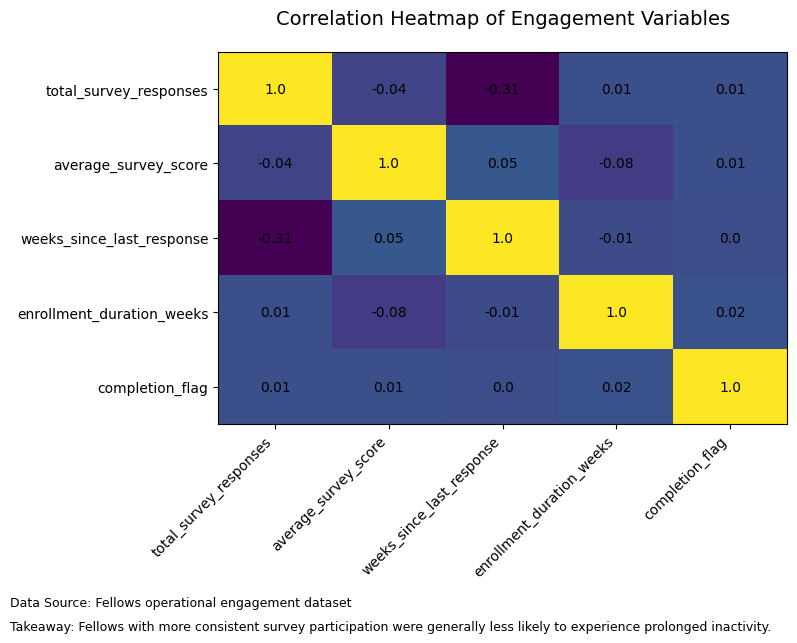

In [86]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# =========================================================
# PREPARE CORRELATION VARIABLES
# =========================================================

correlation_data = (
    fellows_analysis[
        [
            "total_survey_responses",
            "average_survey_score",
            "weeks_since_last_response",
            "enrollment_duration_weeks",
            "completion_flag"
        ]
    ]
)


# =========================================================
# CREATE CORRELATION MATRIX
# =========================================================

correlation_matrix = (
    correlation_data.corr()
    .round(2)
)


# Display correlation matrix
display(
    correlation_matrix
)


# =========================================================
# CREATE HEATMAP
# =========================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

heatmap = ax.imshow(
    correlation_matrix,
    aspect="auto"
)


# Axis labels
ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_yticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_matrix.columns
)


# Add correlation values inside cells
for i in range(len(correlation_matrix.columns)):

    for j in range(len(correlation_matrix.columns)):

        ax.text(
            j,
            i,
            correlation_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=10
        )


# Titles and labels
plt.title(
    "Correlation Heatmap of Engagement Variables",
    fontsize=14,
    pad=20
)

plt.figtext(
    0.01,
    -0.02,
    "Data Source: Fellows operational engagement dataset",
    fontsize=9
)

plt.figtext(
    0.01,
    -0.06,
    "Takeaway: Fellows with more consistent survey participation were generally less likely to experience prolonged inactivity.",
    fontsize=9
)


plt.tight_layout()


# Save chart as PNG
plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


# Display chart
plt.show()

The correlation analysis showed that most of the relationships between the engagement variables were fairly weak. This suggests that fellow engagement is likely influenced by several different operational factors rather than one single variable.

The strongest relationship observed was between:
- total survey responses,
- and weeks since last response,

which recorded a moderate negative correlation of `-0.31`.

In simple terms, fellows who participated in surveys more regularly were generally less likely to stay inactive for long periods.

The analysis also showed that survey scores had very little relationship with completion outcomes. This suggests that participation consistency may be a more useful engagement signal than satisfaction scores alone.

Overall, the findings reinforce the earlier operational analysis, where inactivity and declining participation patterns appeared to be stronger indicators of disengagement risk across the program.

#VISUALISATIONS

### 7.1 Publication Chart Preparation

Before building the final publication-quality charts, the required analytical summary tables were first prepared.

This step helps separate:
- analytical preparation,
- from visualization design,

and makes it easier to validate the final chart inputs before creating the exported visual outputs.

In [94]:
# =========================================================
# LIMIT PUBLICATION VISUALS TO 2024
# =========================================================

fellows_2024 = (

    fellows_analysis[
        fellows_analysis[
            "enrollment_year"
        ] == 2024
    ]

    .copy()
)


# =========================================================
# CREATE MONTH FEATURE
# =========================================================

fellows_2024.loc[
    :,
    "enrollment_month"
] = (

    fellows_2024[
        "enrollment_date"
    ]

    .dt.to_period("M")

    .astype(str)
)


# =========================================================
# CHART 1 TABLE
# MONTHLY PARTICIPATION TREND
# =========================================================

participation_trend_chart_data = (

    fellows_2024.groupby(
        "enrollment_month"
    )

    .size()

    .reset_index(
        name="participant_count"
    )

    .sort_values(
        by="enrollment_month"
    )
)


# =========================================================
# CHART 2 TABLE
# COMPLETIONS BY TRACK
# =========================================================

track_completion_chart_data = (

    fellows_2024.groupby(
        "track"
    )["completion_flag"]

    .sum()

    .reset_index(
        name="completed_fellows"
    )

    .sort_values(
        by="completed_fellows",
        ascending=False
    )
)


# =========================================================
# CHART 3 TABLE
# PARTICIPANTS BY REGION
# =========================================================

region_participation_chart_data = (

    fellows_2024.groupby(
        "geopolitical_zone"
    )

    .size()

    .reset_index(
        name="participant_count"
    )

    .sort_values(
        by="participant_count",
        ascending=False
    )
)


# =========================================================
# HTML GRID OUTPUT
# =========================================================

from IPython.display import HTML


html_output = f"""

<div style="
    display:grid;
    grid-template-columns:repeat(auto-fit, minmax(420px, 1fr));
    gap:20px;
    margin-top:20px;
">

    <!-- Participation Trend -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:18px;
        background:#f9f9f9;
    ">

        <h3>
            Monthly Participation Trend
        </h3>

        {participation_trend_chart_data.to_html(index=False)}

    </div>


    <!-- Completion by Track -->
    <div style="
        border:1px solid #dcdcdc;
        border-radius:12px;
        padding:18px;
        background:#f9f9f9;
    ">

        <h3>
            Completion by Track
        </h3>

        {track_completion_chart_data.to_html(index=False)}

    </div>

</div>


<br>


<div style="
    width:500px;
    border:1px solid #dcdcdc;
    border-radius:12px;
    padding:18px;
    background:#f9f9f9;
">

    <h3>
        Participants by Region
    </h3>

    {region_participation_chart_data.to_html(index=False)}

</div>

"""


display(
    HTML(html_output)
)

enrollment_month,participant_count
2024-01,45
2024-02,106
2024-03,138
2024-04,116
2024-05,133
2024-06,114
2024-07,115
2024-08,129
2024-09,137
2024-10,109


## 7.2 Publication-Quality Visualizations

The following charts were developed to summarize the key operational findings from the analysis.

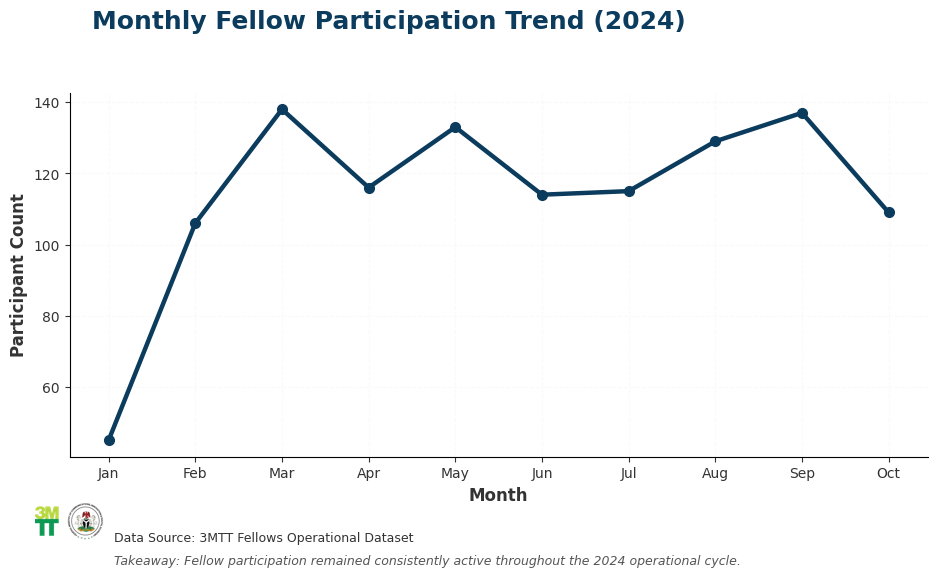

In [119]:
# =========================================================
# CHART 1
# MONTHLY PARTICIPATION TREND
# =========================================================

# Format month labels
participation_trend_chart_data["month_label"] = pd.to_datetime(
    participation_trend_chart_data["enrollment_month"]
).dt.strftime("%b")


# =========================================================
# MASTER FIGURE SIZE
# =========================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


# =========================================================
# MASTER SAFE ZONES
# =========================================================

HEADER_Y = 0.91

TOP_PADDING = 0.80
BOTTOM_PADDING = 0.24

LEFT_PADDING = 0.16
RIGHT_PADDING = 0.94

SOURCE_Y = 0.11
TAKEAWAY_Y = 0.075


# =========================================================
# PLOT TREND LINE
# =========================================================

ax.plot(

    participation_trend_chart_data[
        "month_label"
    ],

    participation_trend_chart_data[
        "participant_count"
    ],

    linewidth=3.2,

    marker="o",

    markersize=7,

    color=PRIMARY_BLUE
)


# =========================================================
# AXIS LABELS
# =========================================================

ax.set_xlabel(

    "Month",

    fontsize=12,

    fontweight="bold",

    color=TEXT_DARK
)


ax.set_ylabel(

    "Participant Count",

    fontsize=12,

    fontweight="bold",

    color=TEXT_DARK
)


# =========================================================
# TICK STYLING
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=10,
    colors=TEXT_DARK
)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors=TEXT_DARK
)


# =========================================================
# GRIDLINES
# =========================================================

ax.grid(

    linestyle="--",

    alpha=0.12,

    color=GRID_LIGHT
)


# =========================================================
# REMOVE UNNECESSARY BORDERS
# =========================================================

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)


# =========================================================
# HEADER TITLE
# =========================================================

fig.text(

    0.18,

    HEADER_Y,

    "Monthly Fellow Participation Trend (2024)",

    fontsize=18,

    fontweight="bold",

    color=PRIMARY_BLUE,

    va="center"
)


# =========================================================
# FOOTER LOGO
# =========================================================

logo_resized = logo.resize(
    (70, 40)
)


fig.figimage(

    logo_resized,

    xo=35,

    yo=36,

    alpha=0.95,

    zorder=10
)


# =========================================================
# SOURCE NOTE
# =========================================================

plt.figtext(

    0.20,

    SOURCE_Y,

    "Data Source: 3MTT Fellows Operational Dataset",

    fontsize=9,

    color=TEXT_DARK
)


# =========================================================
# TAKEAWAY
# =========================================================

plt.figtext(

    0.20,

    TAKEAWAY_Y,

    "Takeaway: Fellow participation remained consistently active throughout the 2024 operational cycle.",

    fontsize=9,

    style="italic",

    color=TAKEAWAY_GREY
)


# =========================================================
# APPLY STRUCTURAL GRID
# =========================================================

plt.subplots_adjust(

    top=TOP_PADDING,

    bottom=BOTTOM_PADDING,

    left=LEFT_PADDING,

    right=RIGHT_PADDING
)


# =========================================================
# EXPORT CHART
# =========================================================

plt.savefig(

    "chart_1_participation_trend.png",

    dpi=300,

    facecolor="white"
)


# =========================================================
# DISPLAY CHART
# =========================================================

plt.show()

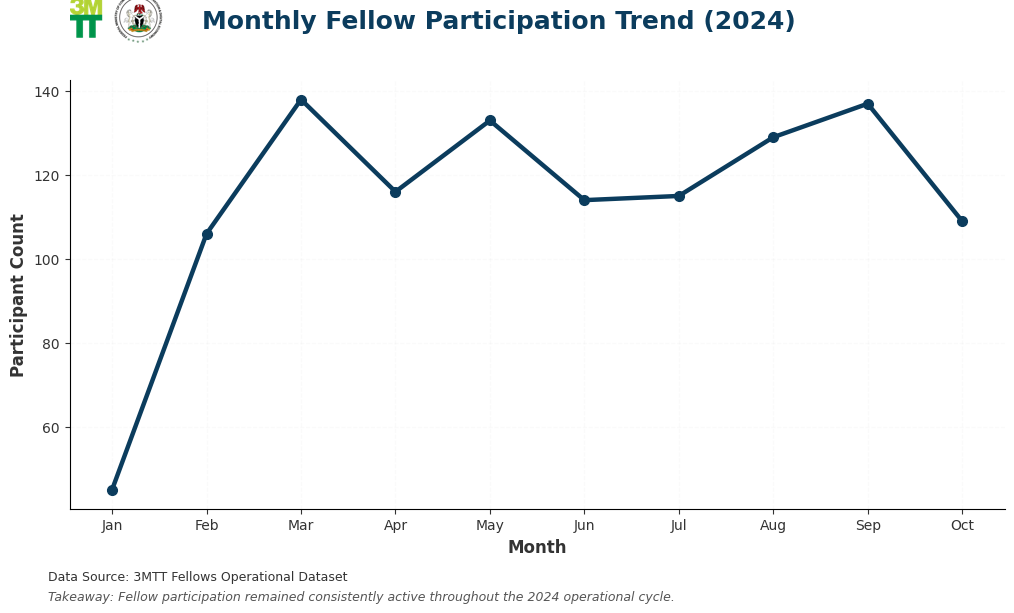

In [108]:
# =========================================================
# CHART 1
# MONTHLY PARTICIPATION TREND
# =========================================================

# Format month labels
participation_trend_chart_data["month_label"] = pd.to_datetime(
    participation_trend_chart_data["enrollment_month"]
).dt.strftime("%b")


# =========================================================
# CREATE FIGURE AND AXIS
# =========================================================

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


# =========================================================
# DEFINE VISUAL LAYOUT GRID
# =========================================================

# HEADER BAND
HEADER_Y = 0.93

# FOOTER POSITIONS
SOURCE_Y = 0.07
TAKEAWAY_Y = 0.04

# CHART BODY AREA
TOP_PADDING = 0.84
BOTTOM_PADDING = 0.18
LEFT_PADDING = 0.10
RIGHT_PADDING = 0.95


# =========================================================
# PLOT TREND LINE
# =========================================================

ax.plot(

    participation_trend_chart_data[
        "month_label"
    ],

    participation_trend_chart_data[
        "participant_count"
    ],

    linewidth=3.2,

    marker="o",

    markersize=7,

    color=PRIMARY_BLUE
)


# =========================================================
# AXIS LABELS
# =========================================================

ax.set_xlabel(

    "Month",

    fontsize=12,

    fontweight="bold",

    color=TEXT_DARK
)


ax.set_ylabel(

    "Participant Count",

    fontsize=12,

    fontweight="bold",

    color=TEXT_DARK
)


# =========================================================
# TICK STYLING
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=10,
    colors=TEXT_DARK
)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors=TEXT_DARK
)


# =========================================================
# GRIDLINES
# =========================================================

ax.grid(

    linestyle="--",

    alpha=0.12,

    color=GRID_LIGHT
)


# =========================================================
# REMOVE UNNECESSARY BORDERS
# =========================================================

ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)


# =========================================================
# RESIZE LOGO
# =========================================================

logo_resized = logo.resize(
    (95, 55)
)


# =========================================================
# ADD HEADER LOGO
# =========================================================

fig.figimage(

    logo_resized,

    xo=70,

    yo=fig.bbox.height - 82,

    alpha=1,

    zorder=10
)


# =========================================================
# HEADER TITLE
# =========================================================

fig.text(

    0.22,

    HEADER_Y,

    "Monthly Fellow Participation Trend (2024)",

    fontsize=18,

    fontweight="bold",

    color=PRIMARY_BLUE,

    va="center"
)


# =========================================================
# SOURCE NOTE
# =========================================================

plt.figtext(

    0.08,

    SOURCE_Y,

    "Data Source: 3MTT Fellows Operational Dataset",

    fontsize=9,

    color=TEXT_DARK
)


# =========================================================
# TAKEAWAY
# =========================================================

plt.figtext(

    0.08,

    TAKEAWAY_Y,

    "Takeaway: Fellow participation remained consistently active throughout the 2024 operational cycle.",

    fontsize=9,

    style="italic",

    color=TAKEAWAY_GREY
)


# =========================================================
# APPLY LAYOUT GRID
# =========================================================

plt.subplots_adjust(

    top=TOP_PADDING,

    bottom=BOTTOM_PADDING,

    left=LEFT_PADDING,

    right=RIGHT_PADDING
)


# =========================================================
# EXPORT CHART
# =========================================================

plt.savefig(

    "chart_1_participation_trend.png",

    dpi=300,

    bbox_inches="tight"
)


# =========================================================
# DISPLAY CHART
# =========================================================

plt.show()